# Project objective

# Exploratory Data Analysis
The objective of this Exploratory Data Analysis (EDA) is to identify workforce trends, AI adoption patterns, hiring behavior, salary distribution, automation risk, and future employment opportunities.

The analysis focuses on answering predefined stakeholder business questions and generating actionable business insights instead of producing descriptive visualizations alone.

# Import Libraries


In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

# Load Dataset

In [7]:
df=pd.read_csv('/content/AI_Impact_on_Jobs_2030.csv')
df.head(5)

,Employee_ID,Job_Title,Industry,Country,Education_Level,Years_Experience,AI_Replacement_Risk,Future_Demand_Score,Remote_Work_Possibility,Average_Salary_USD,Required_Skills,Automation_Level,Job_Growth_2030,Work_Hours_Per_Week,Company_Size,AI_Tool_Usage,Performance_Score,Upskilling_Needed,Job_Satisfaction,Hiring_Trend_2026
0,AIJ-100000,Data Engineer,Healthcare,Japan,PhD,1,0.25,0.78,Yes,207392,"Python, Communication, Deep Learning",Low,3,37,Enterprise,High,2.08,Yes,3.86,Growing
1,AIJ-100001,Healthcare Analyst,Retail,UK,Bachelor,24,0.73,0.33,No,140785,"Deep Learning, Azure, Communication, TensorFlo...",Low,-5,42,Startup,Moderate,4.54,No,4.23,Growing
2,AIJ-100002,HR Specialist,Education,Canada,High School,21,0.80,0.69,Yes,124800,"Kubernetes, Cloud Computing, TensorFlow, SQL, ...",Medium,-5,57,Startup,Low,3.14,No,3.54,Stable
3,AIJ-100003,Cybersecurity Analyst,Government,UK,Bachelor,5,0.29,0.94,No,199878,"Excel, Kubernetes, Prompt Engineering, Leadership",Medium,7,59,Enterprise,High,3.67,No,4.37,Declining
4,AIJ-100004,Healthcare Analyst,Education,UAE,PhD,20,0.11,0.92,No,178682,"SQL, Leadership, TensorFlow, Cybersecurity",Low,6,34,Startup,High,3.68,No,3.99,Stable


# Exploratory Data Analysis (EDA)

## 1. Univariate Analysis

### 1.1 Industry


### Business Question

Which industries are represented in the dataset, and what does their distribution indicate about the workforce sectors expected to be influenced by AI by 2030?

In [8]:
industry_count = (
    df["Industry"]
    .value_counts()
    .reset_index()
)

industry_count.columns = ["Industry", "Count"]

industry_count["Percentage"] = (
    industry_count["Count"] / len(df) * 100
).round(2)

industry_count

,Industry,Count,Percentage
0,Energy,335,11.17
1,Government,323,10.77
2,Finance,310,10.33
3,Manufacturing,303,10.10
4,Education,300,10.00
5,Transportation,293,9.77
6,Technology,291,9.70
7,Media,287,9.57
8,Retail,285,9.50
9,Healthcare,273,9.10


/tmp/ipykernel_3412/3611354069.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


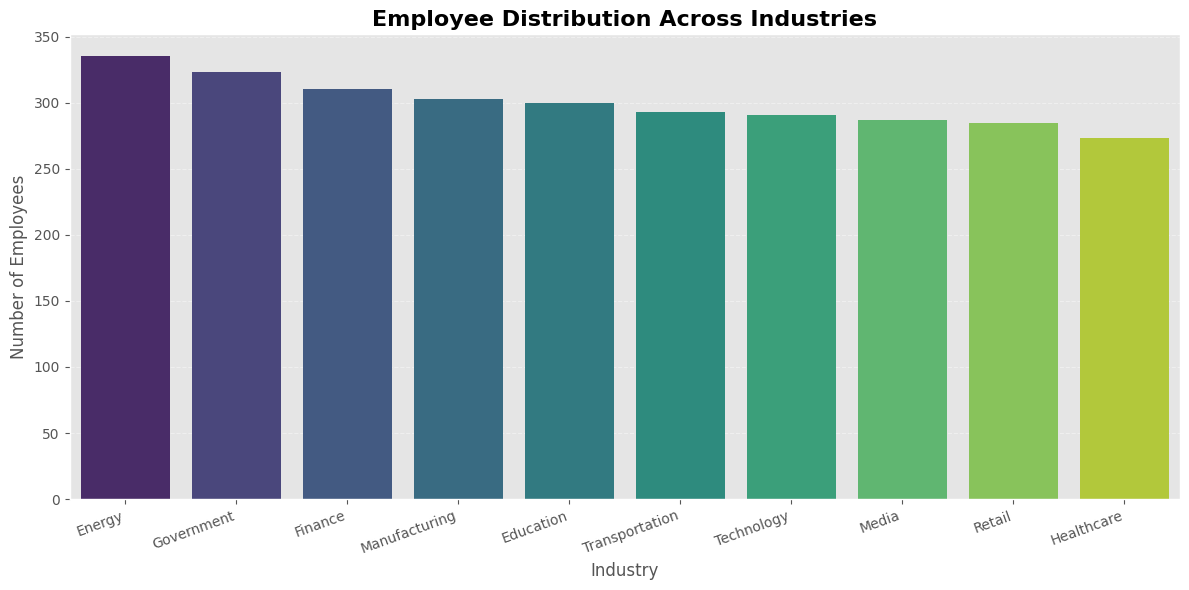

In [9]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x="Industry",
    order=df["Industry"].value_counts().index,
    palette="viridis"
)

plt.title("Employee Distribution Across Industries", fontsize=16, fontweight='bold')
plt.xlabel("Industry")
plt.ylabel("Number of Employees")

plt.xticks(rotation=20, ha="right")

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()

plt.show()

### Observation

The dataset contains employees from ten different industries with a relatively balanced distribution. The Energy sector represents the largest share (11.17%), followed closely by Government (10.77%) and Finance (10.33%). Healthcare has the lowest representation (9.10%). Overall, no single industry dominates the dataset, indicating that the analysis captures a diverse workforce across multiple sectors.

### Business Insight

The balanced industry distribution suggests that the dataset is well suited for cross-industry comparisons of AI adoption, automation risk, hiring trends, and workforce transformation. Since no sector is significantly overrepresented, the insights derived later are less likely to be biased toward a particular industry.

### Executive Recommendation

Organizations should evaluate AI readiness on an industry-specific basis rather than assuming uniform adoption across sectors. Subsequent analyses should focus on comparing automation risk, future demand, and salary trends across industries to identify where AI-driven workforce transformation is expected to be most significant.

### 1.2 Country


### Business Question

Which countries are represented in the dataset, and how is the workforce distributed geographically?

In [10]:
country_count = (
    df["Country"]
    .value_counts()
    .reset_index()
)

country_count.columns = ["Country", "Count"]

country_count["Percentage"] = (
    country_count["Count"] / len(df) * 100
).round(2)

country_count

,Country,Count,Percentage
0,UAE,347,11.57
1,Germany,318,10.60
2,Australia,312,10.40
3,Pakistan,300,10.00
4,Japan,299,9.97
5,UK,298,9.93
6,USA,295,9.83
7,Canada,285,9.50
8,India,279,9.30
9,Singapore,267,8.90


/tmp/ipykernel_3412/1408107691.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


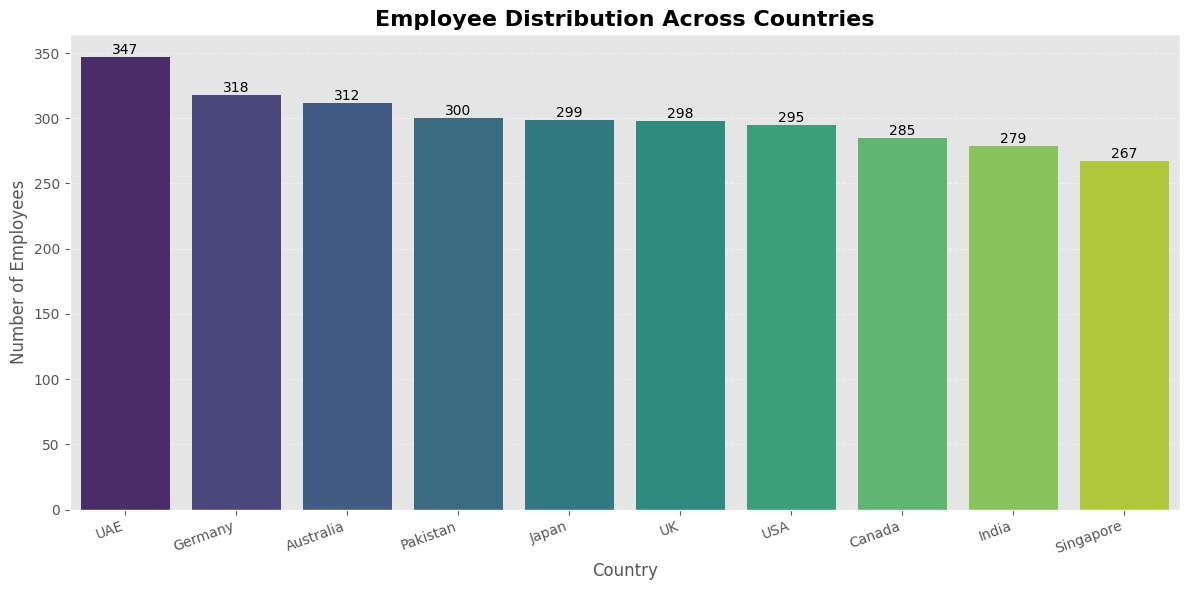

In [11]:
plt.figure(figsize=(12,6))

ax = sns.countplot(
    data=df,
    x="Country",
    order=df["Country"].value_counts().index,
    palette="viridis"
)

plt.title(
    "Employee Distribution Across Countries",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Country")
plt.ylabel("Number of Employees")

plt.xticks(rotation=20, ha="right")

for container in ax.containers:
    ax.bar_label(container)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

### Observation

The dataset represents employees from ten countries with a relatively balanced geographic distribution. The UAE contributes the largest share of employees (11.57%), followed by Germany (10.60%) and Australia (10.40%). Singapore has the lowest representation (8.90%). Overall, the distribution indicates that no single country dominates the dataset.

### Business Insight

The balanced representation across countries enables meaningful geographical comparisons throughout the analysis. Since the workforce is not concentrated in a single region, subsequent analyses of AI replacement risk, hiring trends, salary distribution, and future job demand can be compared across multiple national contexts with reduced sampling bias.

### Executive Recommendation

Organizations operating across multiple countries should avoid adopting a one-size-fits-all AI workforce strategy. Future analyses should compare automation risk, salary trends, and future demand by country to identify region-specific workforce planning and reskilling priorities.

### Key Takeaway

The dataset provides a geographically balanced workforce, making it suitable for analyzing regional differences in AI adoption, workforce transformation, and employment trends.

### 1.3 Company Size

### Business Question

How are employees distributed across different company sizes, and what does this indicate about the organizational landscape represented in the dataset?

In [12]:
df["Job_Title"].nunique()

20

In [13]:
company_size_count = (
    df["Company_Size"]
    .value_counts()
    .reset_index()
)

company_size_count.columns = ["Company Size", "Count"]

company_size_count["Percentage"] = (
    company_size_count["Count"] / len(df) * 100
).round(2)

company_size_count

,Company Size,Count,Percentage
0,Medium,1025,34.17
1,Enterprise,990,33.00
2,Startup,985,32.83


/tmp/ipykernel_3412/627360279.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


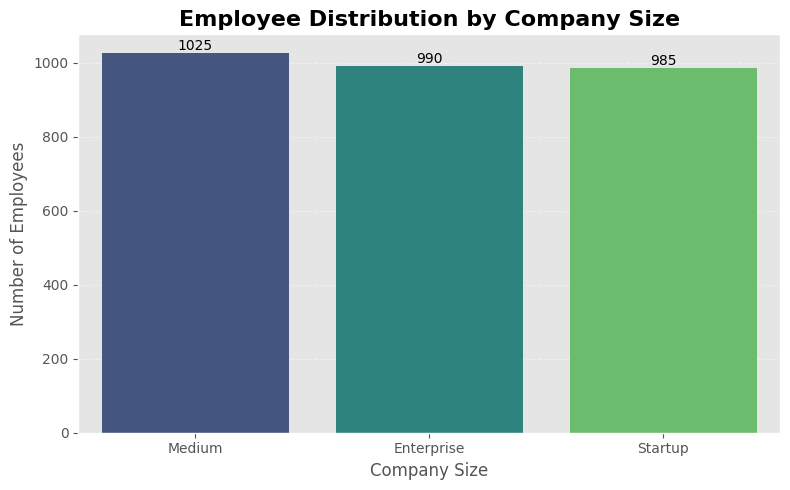

In [14]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="Company_Size",
    order=df["Company_Size"].value_counts().index,
    palette="viridis"
)

plt.title(
    "Employee Distribution by Company Size",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Company Size")
plt.ylabel("Number of Employees")

for container in ax.containers:
    ax.bar_label(container)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

### Observation

The dataset represents organizations of three different sizes with an almost equal distribution. Medium-sized companies account for the largest share (34.17%), followed by Enterprise organizations (33.00%) and Startups (32.83%). The differences between categories are minimal, indicating a well-balanced representation of organizations of varying scales.

### Business Insight

The balanced representation of startups, medium-sized businesses, and enterprises enables meaningful comparisons of AI adoption, workforce transformation, hiring trends, and automation across different organizational scales without introducing significant sampling bias.

### Executive Recommendation

Organizations should evaluate AI adoption strategies according to their organizational scale. Subsequent analyses should investigate whether company size influences AI replacement risk, future hiring demand, salary levels, and employee upskilling requirements.

###1.4 Job Roles

### Business Question

Which job roles are most frequently represented in the dataset, and what does their distribution indicate about the workforce composition considered in the AI impact analysis?

In [15]:
job_title_count = (
    df["Job_Title"]
    .value_counts()
    .reset_index()
)

job_title_count.columns = ["Job Role", "Count"]

job_title_count["Percentage"] = (
    job_title_count["Count"] / len(df) * 100
).round(2)

job_title_count

,Job Role,Count,Percentage
0,Software Developer,164,5.47
1,HR Specialist,163,5.43
2,Robotics Engineer,162,5.40
3,Cybersecurity Analyst,162,5.40
4,UX Designer,158,5.27
5,Machine Learning Engineer,157,5.23
6,Product Manager,157,5.23
7,Blockchain Developer,155,5.17
8,Teacher,153,5.10
9,DevOps Engineer,152,5.07


/tmp/ipykernel_3412/1233859640.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


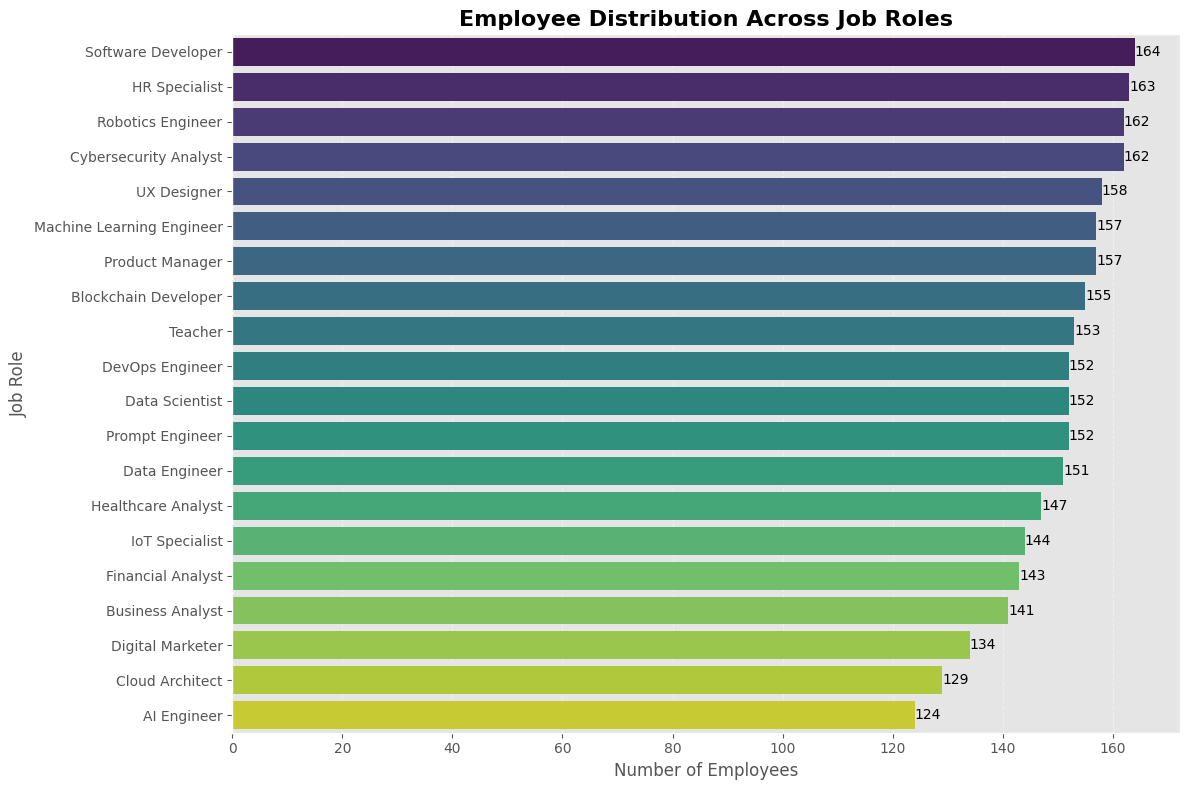

In [16]:
plt.figure(figsize=(12,8))

ax = sns.countplot(
    data=df,
    y="Job_Title",
    order=df["Job_Title"].value_counts().index,
    palette="viridis"
)

plt.title(
    "Employee Distribution Across Job Roles",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Number of Employees")
plt.ylabel("Job Role")

for container in ax.containers:
    ax.bar_label(container)

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

### Observation

The dataset includes 20 different job roles with a relatively balanced distribution across all professions. Software Developers represent the largest group (164 employees, 5.47%), while AI Engineers account for the smallest share (124 employees, 4.13%). The narrow difference in representation indicates that no individual job role dominates the dataset.

### Business Insight

The balanced representation of job roles enables fair comparisons of AI replacement risk, automation levels, salary trends, future demand, and upskilling requirements across different professions. This balanced workforce composition reduces the likelihood of role-specific bias influencing subsequent analyses.

### Executive Recommendation

Organizations should evaluate AI workforce strategies at the job-role level rather than assuming similar impacts across all professions. Subsequent analyses should compare automation risk, future demand, required skills, and salary trends to identify which job roles are most likely to undergo workforce transformation.

### Key Takeaway

The dataset provides a well-balanced representation of diverse job roles, making it suitable for analyzing profession-specific AI workforce trends.

### Business Question

What is the educational composition of the workforce, and what does it reveal about the qualifications expected in an AI-driven job market?

In [17]:
education_count = (
    df["Education_Level"]
    .value_counts()
    .reset_index()
)

education_count.columns = ["Education Level", "Count"]

education_count["Percentage"] = (
    education_count["Count"] / len(df) * 100
).round(2)

education_count

,Education Level,Count,Percentage
0,Bachelor,782,26.07
1,PhD,779,25.97
2,High School,727,24.23
3,Master,712,23.73


/tmp/ipykernel_3412/3339169561.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


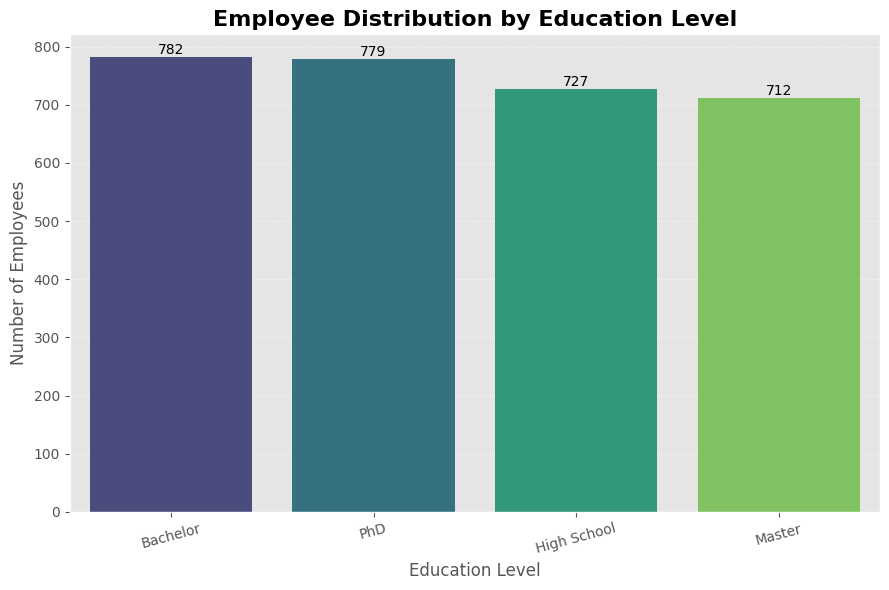

In [18]:
plt.figure(figsize=(9,6))

ax = sns.countplot(
    data=df,
    x="Education_Level",
    order=df["Education_Level"].value_counts().index,
    palette="viridis"
)

plt.title(
    "Employee Distribution by Education Level",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Education Level")
plt.ylabel("Number of Employees")

plt.xticks(rotation=15)

for container in ax.containers:
    ax.bar_label(container)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

### Observation

The workforce is distributed across four educational levels with minimal variation in representation. Bachelor's degree holders account for the highest share (26.07%), closely followed by PhD holders (25.97%), while Master's degree holders represent the smallest group (23.73%). The narrow differences indicate that the dataset captures employees from diverse educational backgrounds without any single qualification dominating the workforce.

### Observation

The workforce is distributed across four educational levels with minimal variation in representation. Bachelor's degree holders account for the highest share (26.07%), closely followed by PhD holders (25.97%), while Master's degree holders represent the smallest group (23.73%). The narrow differences indicate that the dataset captures employees from diverse educational backgrounds without any single qualification dominating the workforce.

### Executive Recommendation

Organizations should assess AI workforce strategies across all education levels rather than assuming higher educational qualifications alone provide protection against automation. Future analyses should compare AI replacement risk, salary trends, and future demand by education level to identify where targeted upskilling initiatives may be required.

### Key Takeaway

The dataset represents employees from diverse educational backgrounds, providing a balanced foundation for evaluating how education influences workforce transformation in the age of AI.

### Business Question

What is the experience distribution of the workforce, and what does it reveal about the maturity of employees expected to work in an AI-driven job market?

In [19]:
experience_summary = df["Years_Experience"].describe().to_frame()

experience_summary

,Years_Experience
count,3000.000000
mean,12.383000
std,7.528958
min,0.000000
25%,6.000000
50%,12.000000
75%,19.000000
max,25.000000


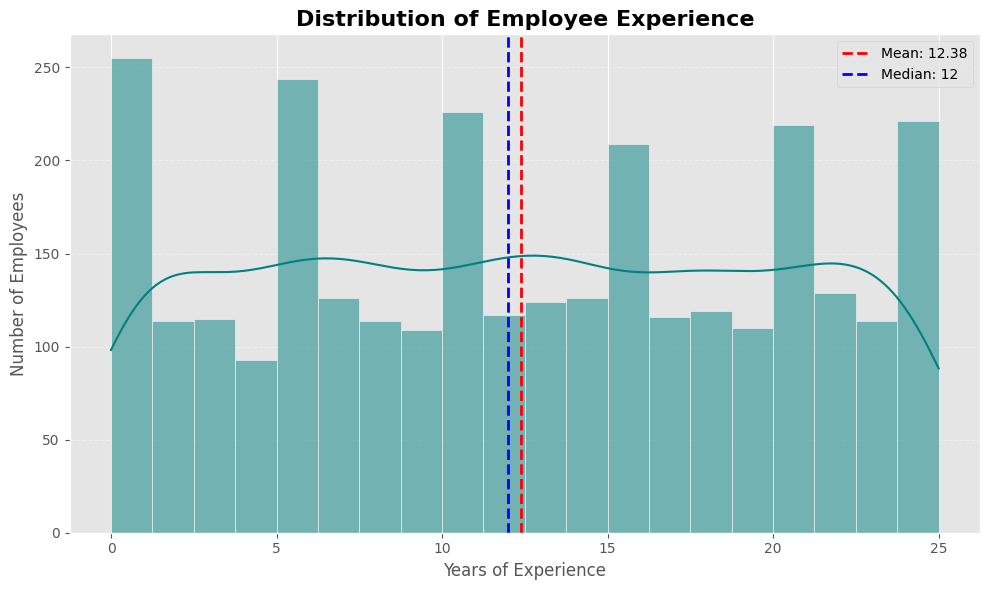

In [22]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="Years_Experience",
    bins=20,
    kde=True,
    color="teal"
)

# Mean
plt.axvline(
    df["Years_Experience"].mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean: {df['Years_Experience'].mean():.2f}"
)

# Median
plt.axvline(
    df["Years_Experience"].median(),
    color="blue",
    linestyle="--",
    linewidth=2,
    label=f"Median: {df['Years_Experience'].median():.0f}"
)

plt.title(
    "Distribution of Employee Experience",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Years of Experience")
plt.ylabel("Number of Employees")

plt.legend()

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

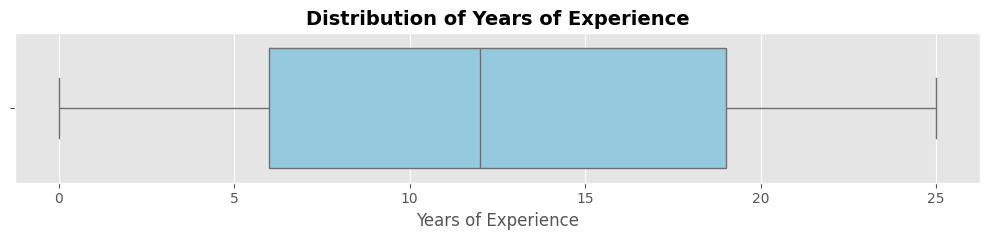

In [21]:
plt.figure(figsize=(10,2.5))

sns.boxplot(
    x=df["Years_Experience"],
    color="skyblue"
)

plt.title(
    "Distribution of Years of Experience",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Years of Experience")

plt.tight_layout()

plt.show()

### Observation

The workforce has an average of approximately 12.4 years of experience, with experience ranging from 0 to 25 years. The mean (12.38 years) and median (12 years) are nearly identical, indicating a fairly balanced distribution of experience levels. Furthermore, the absence of significant outliers suggests that the dataset captures employees across different career stages without abnormal experience values.

### Business Insight

The balanced distribution of experience levels enables comprehensive analysis of how professional experience influences AI replacement risk, future job demand, salary progression, automation exposure, and workforce readiness. Since employees are represented across early-, mid-, and late-career stages, the dataset supports meaningful experience-based comparisons.

### Executive Recommendation

Organizations should evaluate AI workforce strategies across different career stages rather than applying uniform policies. Future analyses should investigate whether experience influences automation risk, salary growth, upskilling requirements, and long-term employability.

### Key Takeaway

The dataset represents employees across all career stages with a balanced experience distribution, making it suitable for analyzing the relationship between professional experience and AI-driven workforce transformation.

### Required Skills

In [25]:
all_skills = (
    df["Required_Skills"]
    .str.split(", ")
    .explode()
)

skill_count = (
    all_skills
    .value_counts()
    .reset_index()
)

skill_count.columns = ["Skill", "Count"]

skill_count["Percentage"] = (
    skill_count["Count"] / len(df) * 100
).round(2)

skill_count

,Skill,Count,Percentage
0,Cloud Computing,785,26.17
1,Leadership,778,25.93
2,Cybersecurity,776,25.87
3,Communication,776,25.87
4,Azure,772,25.73
5,Deep Learning,770,25.67
6,Machine Learning,765,25.50
7,TensorFlow,762,25.40
8,Data Visualization,751,25.03
9,Kubernetes,750,25.00


In [23]:
df["Required_Skills"].nunique()

2937

In [24]:
df["Required_Skills"].value_counts()

,count
Required_Skills,
"Cloud Computing, Kubernetes, Leadership",3
"Communication, PyTorch, Excel",3
"TensorFlow, Deep Learning, AWS",2
"Docker, Data Visualization, TensorFlow",2
"Data Visualization, Docker, Leadership, Excel",2
...,...
"Kubernetes, Leadership, AWS",1
"Azure, Excel, Kubernetes, Machine Learning, Communication",1
"Cybersecurity, Project Management, Prompt Engineering",1


/tmp/ipykernel_3412/2354061427.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


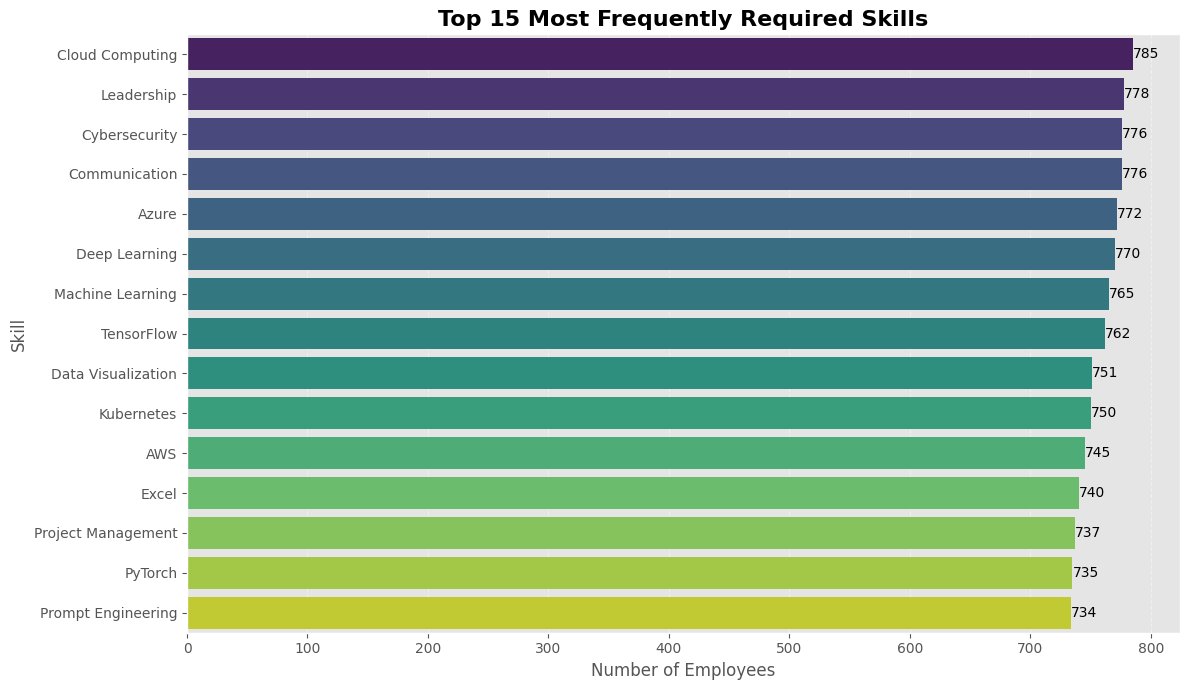

In [26]:
top_skills = skill_count.head(15)

plt.figure(figsize=(12,7))

ax = sns.barplot(
    data=top_skills,
    x="Count",
    y="Skill",
    palette="viridis"
)

plt.title(
    "Top 15 Most Frequently Required Skills",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Number of Employees")

plt.ylabel("Skill")

for container in ax.containers:
    ax.bar_label(container)

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

### Observation

The workforce demonstrates a diverse mix of technical and professional skills, with Cloud Computing (26.17%), Leadership (25.93%), Cybersecurity (25.87%), and Communication (25.87%) being the most frequently required competencies. The relatively small variation across skill frequencies indicates that the dataset captures a balanced representation of both technical expertise and workplace competencies.

### Business Insight

The balanced distribution of technical and professional skills enables comprehensive evaluation of workforce readiness for AI adoption. The presence of cloud technologies, machine learning frameworks, cybersecurity, communication, and leadership highlights that future workforce success depends on a combination of technical capabilities and human-centric skills rather than programming knowledge alone.

### Executive Recommendation

Organizations should design workforce development strategies that strengthen both technical and interpersonal competencies. Future analyses should investigate how specific skills influence AI replacement risk, future job demand, salary progression, and employee performance to identify the most valuable competencies in an AI-driven workforce.

### Key Takeaway

The workforce possesses a balanced combination of emerging technologies, analytical capabilities, and professional skills, providing a strong foundation for evaluating future workforce readiness and AI transformation.